In [36]:
import pandas as pd
import numpy as np
import json
import shap
import joblib
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, average_precision_score
import xgboost as xgb
from sklearn.metrics import classification_report, roc_auc_score, average_precision_score
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.model_selection import RandomizedSearchCV


In [2]:
data = pd.read_csv('adult.data', header=None, names=['age', 'workclass', 'fnlwgt', 'education','education-num', 'marital-status',
'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss',
'hours-per-week', 'native-country', 'income'], skipinitialspace=True)
data.head(5)

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education-num   32561 non-null  int64 
 5   marital-status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital-gain    32561 non-null  int64 
 11  capital-loss    32561 non-null  int64 
 12  hours-per-week  32561 non-null  int64 
 13  native-country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [8]:
data['workclass'].unique()

array(['State-gov', 'Self-emp-not-inc', 'Private', 'Federal-gov',
       'Local-gov', '?', 'Self-emp-inc', 'Without-pay', 'Never-worked'],
      dtype=object)

In [9]:
data['income'].unique()

array(['<=50K', '>50K'], dtype=object)

In [10]:
for i in data:
    print(data[i].value_counts())

age
36    898
31    888
34    886
23    877
35    876
     ... 
83      6
88      3
85      3
86      1
87      1
Name: count, Length: 73, dtype: int64
workclass
Private             22696
Self-emp-not-inc     2541
Local-gov            2093
?                    1836
State-gov            1298
Self-emp-inc         1116
Federal-gov           960
Without-pay            14
Never-worked            7
Name: count, dtype: int64
fnlwgt
123011    13
164190    13
203488    13
121124    12
126675    12
          ..
316185     1
292353     1
205019     1
180296     1
422249     1
Name: count, Length: 21648, dtype: int64
education
HS-grad         10501
Some-college     7291
Bachelors        5355
Masters          1723
Assoc-voc        1382
11th             1175
Assoc-acdm       1067
10th              933
7th-8th           646
Prof-school       576
9th               514
12th              433
Doctorate         413
5th-6th           333
1st-4th           168
Preschool          51
Name: count, dtype: int64

In [3]:
#melihat hubungan education-num dan education
data.groupby('education')['education-num'].unique()

education
10th             [6]
11th             [7]
12th             [8]
1st-4th          [2]
5th-6th          [3]
7th-8th          [4]
9th              [5]
Assoc-acdm      [12]
Assoc-voc       [11]
Bachelors       [13]
Doctorate       [16]
HS-grad          [9]
Masters         [14]
Preschool        [1]
Prof-school     [15]
Some-college    [10]
Name: education-num, dtype: object

In [3]:
# 1. Hitung value_counts dari native-country
country_counts = data['native-country'].value_counts()

# 2. Filter negara dengan count < 100, ambil NAMA-nya (index), bukan angkanya
rare_countries = country_counts[country_counts < 100].index

# 3. Ganti semua negara langka itu jadi "Other"
data['native-country'] = data['native-country'].replace(rare_countries, 'Other')

# 4. Verifikasi
print(data['native-country'].value_counts())

native-country
United-States    29170
Other             1389
Mexico             643
?                  583
Philippines        198
Germany            137
Canada             121
Puerto-Rico        114
El-Salvador        106
India              100
Name: count, dtype: int64


In [3]:
data['workclass_missing'] = (data['workclass'] =='?')
data['workclass'] = data['workclass'].replace('?', np.nan)

data['occupation_missing'] = (data['occupation'] == '?')
data['occupation'] = data['occupation'].replace('?', np.nan)

data['native-country_missing'] = (data['native-country'] == '?')
data['native-country'] = data['native-country'].replace('?', np.nan)

print(data['workclass'].isnull().sum())
print(data['workclass_missing'].sum())

print(data['occupation'].isnull().sum())
print(data['occupation_missing'].sum())

print(data['native-country'].isnull().sum())
print(data['native-country_missing'].sum())

1836
1836
1843
1843
583
583


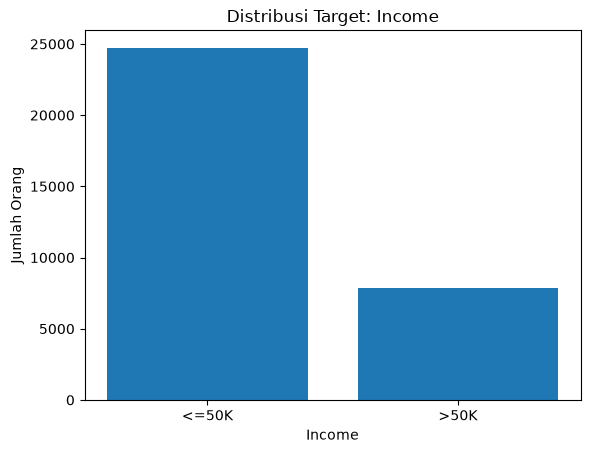

In [5]:
income_counts = data['income'].value_counts()
plt.bar(income_counts.index, income_counts.values)
plt.xlabel('Income')
plt.ylabel('Jumlah Orang')
plt.title('Distribusi Target: Income')
plt.show()

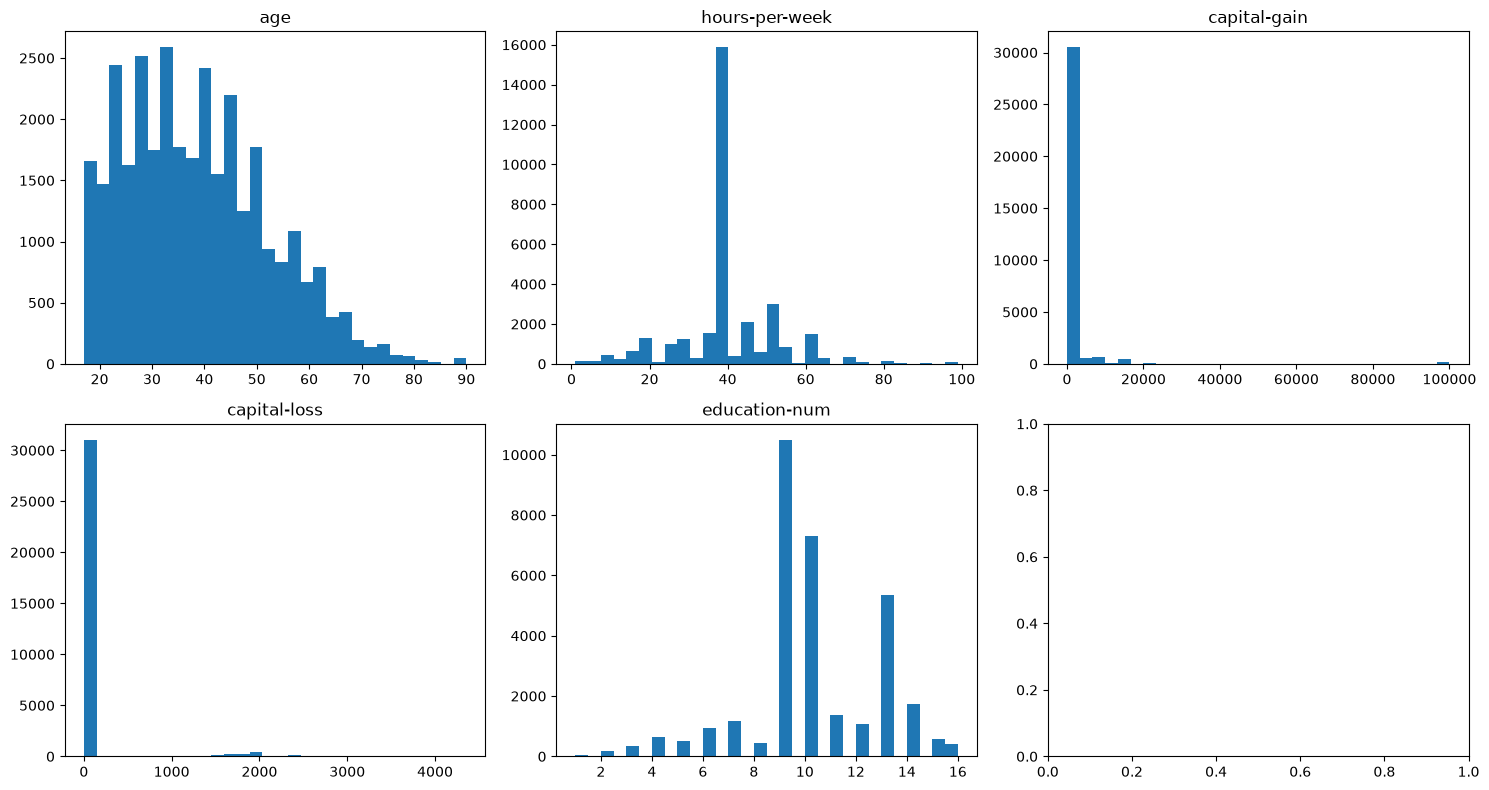

In [6]:
numeric_cols = ['age', 'hours-per-week', 'capital-gain', 'capital-loss', 'education-num']

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 8))

for ax, col in zip(axes.flatten(), numeric_cols):
    ax.hist(data[col], bins=30)
    ax.set_title(col)
plt.tight_layout()
plt.show()

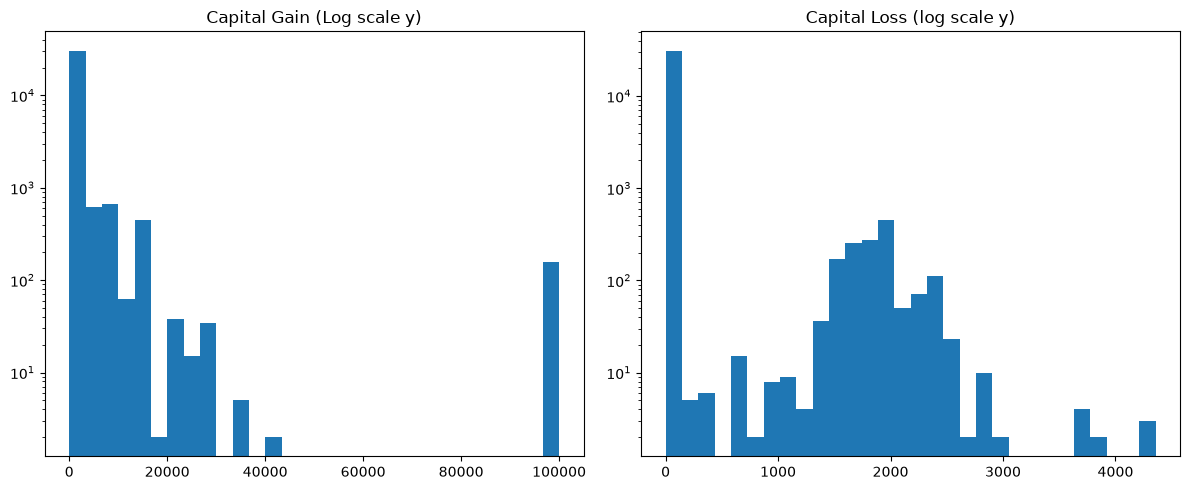

In [8]:
fig, axes = plt.subplots(1,2,figsize=(12,5))

axes[0].hist(data['capital-gain'], bins= 30)
axes[0].set_yscale('log')
axes[0].set_title('Capital Gain (Log scale y)')

axes[1].hist(data['capital-loss'], bins = 30)
axes[1].set_yscale('log')
axes[1].set_title('Capital Loss (log scale y)')

plt.tight_layout()
plt.show()

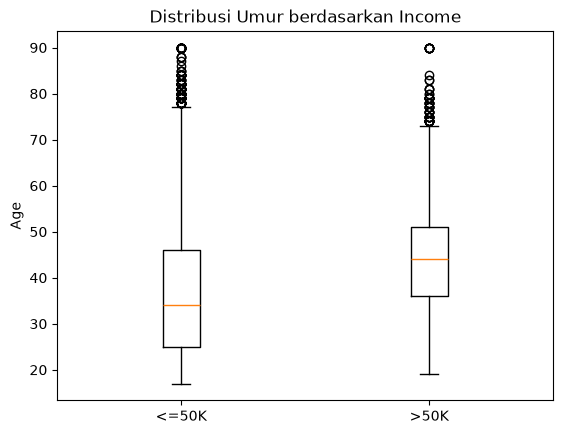

In [11]:
group_50k_bawah =data[data['income']=='<=50K']['age']
group_50k_atas = data[data['income'] =='>50K']['age']

plt.boxplot([group_50k_bawah, group_50k_atas], tick_labels=['<=50K', '>50K'])
plt.ylabel('Age')
plt.title('Distribusi Umur berdasarkan Income')
plt.show()

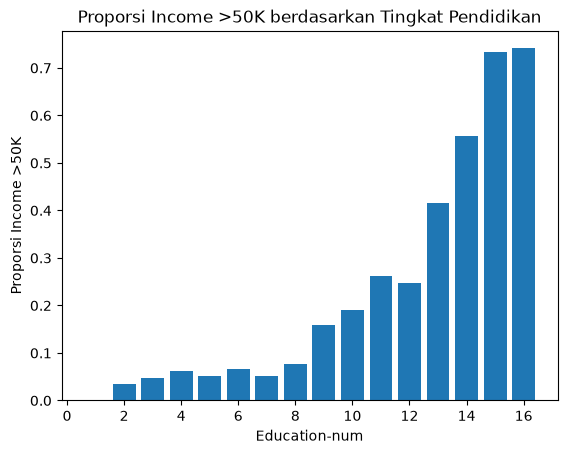

In [12]:
edu_income = data.groupby('education-num')['income'].apply(lambda x: (x == '>50K').mean())

plt.bar(edu_income.index, edu_income.values)
plt.xlabel('Education-num')
plt.ylabel('Proporsi Income >50K')
plt.title('Proporsi Income >50K berdasarkan Tingkat Pendidikan')
plt.show()

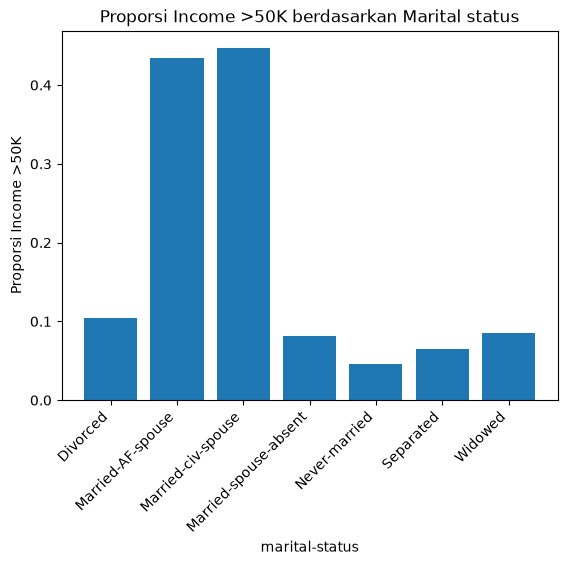

In [14]:
edu_income = data.groupby('marital-status')['income'].apply(lambda x: (x == '>50K').mean())

plt.bar(edu_income.index, edu_income.values)
plt.xlabel('marital-status')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Proporsi Income >50K')
plt.title('Proporsi Income >50K berdasarkan Marital status')
plt.show()

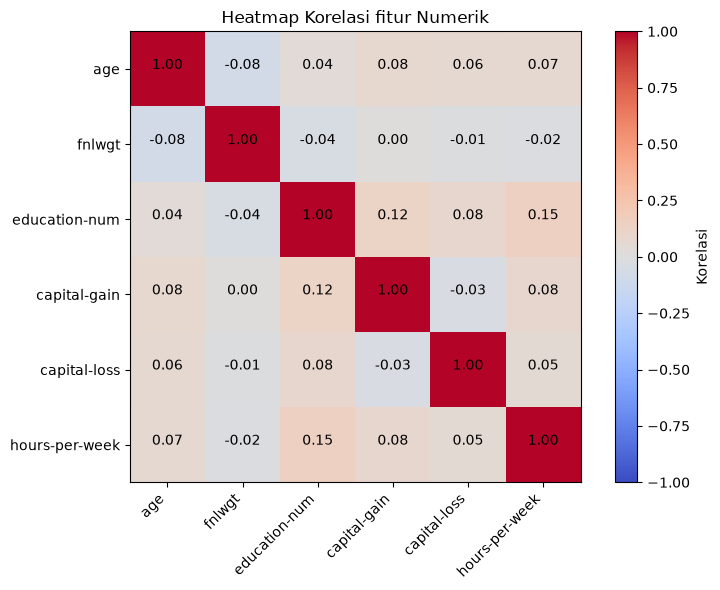

In [4]:
#EDA
numeric_cols = ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
corr_matrix = data[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(8,6))
im = ax.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)

ax.set_xticks(range(len(numeric_cols)))
ax.set_yticks(range(len(numeric_cols)))
ax.set_xticklabels(numeric_cols, rotation=45, ha='right')
ax.set_yticklabels(numeric_cols)

for i in range(len(numeric_cols)):
    for j in range(len(numeric_cols)):
        ax.text(j,i, f'{corr_matrix.iloc[i,j]:.2f}', ha='center')
        

plt.colorbar(im, label="Korelasi")
plt.title("Heatmap Korelasi fitur Numerik")
plt.tight_layout()
plt.show()

In [ ]:
'''Sebelum kita lanjut ke encoding & modeling, mari kita rekap semua yang sudah kita temukan:

Target imbalanced (~76% vs 24%) → pakai PR-AUC/recall, bukan accuracy semata
capital-gain/capital-loss sangat sparse (>90% nol) → tidak perlu transformasi khusus untuk XGBoost, tapi worth dicatat di README
hours-per-week menumpuk di 40 (full-time standard) → sinyal asli, bukan anomali
education-num korelasi kuat & monoton dengan income → kandidat fitur penting
marital-status berkorelasi kuat dengan income, kemungkinan proxy untuk usia/tahap karier → catat sebagai korelasi bukan kausalitas
Tidak ada multicollinearity signifikan antar fitur numerik
'''

In [5]:
object_cols = data.select_dtypes(include='object').columns

for i in object_cols:
    data[i] = data[i].astype('category')
    
print(data.dtypes)

age                          int64
workclass                 category
fnlwgt                       int64
education                 category
education-num                int64
marital-status            category
occupation                category
relationship              category
race                      category
sex                       category
capital-gain                 int64
capital-loss                 int64
hours-per-week               int64
native-country            category
income                    category
workclass_missing             bool
occupation_missing            bool
native-country_missing        bool
dtype: object


C:\Users\ASUS\AppData\Local\Temp\ipykernel_2572\951817861.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  object_cols = data.select_dtypes(include='object').columns


In [6]:
data = data.drop(columns=['education'])

In [7]:
data['income'] = (data['income'] == '>50K').astype(int)

In [8]:
print(data.columns.tolist())
print(data['income'].value_counts())

['age', 'workclass', 'fnlwgt', 'education-num', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income', 'workclass_missing', 'occupation_missing', 'native-country_missing']
income
0    24720
1     7841
Name: count, dtype: int64


In [9]:
X = data.drop(columns='income')
y = data['income']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=42, stratify=y)

print(y_train.value_counts(normalize = True))
print(y_test.value_counts(normalize=True))

income
0    0.759175
1    0.240825
Name: proportion, dtype: float64
income
0    0.759251
1    0.240749
Name: proportion, dtype: float64


In [ ]:
#training XGBOOst

model = xgb.XGBClassifier(
    enable_categorical=True, #supaya bida memproses kolom bertipe kategorical
    eval_metric ='aucpr', #nama metric di XGBoost
    random_state = 42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred))
print('PR-AUC', average_precision_score(y_test, y_pred_proba))

'''
Membaca hasil ini

Kelas 0 (<=50K, mayoritas, 4945 sampel):

Precision 0.90, recall 0.94 → model sangat baik mengenali orang berpenghasilan rendah, wajar karena ini kelas mayoritas dan modelnya punya banyak contoh untuk belajar

Kelas 1 (>50K, minoritas, 1568 sampel) — ini yang lebih penting diperhatikan karena imbalanced:

Precision 0.77 → dari semua yang model prediksi >50K, 77% benar-benar >50K (23% false positive)
Recall 0.67 → dari semua orang yang sebenarnya >50K, model cuma berhasil menangkap 67%-nya (33% ke-miss, false negative)

PR-AUC 0.83 → ini metric utama kita untuk data imbalanced, dan angka 0.83 tergolong cukup baik untuk baseline tanpa tuning apa pun (skala 0-1, di mana random guess untuk imbalance 24% positif akan menghasilkan PR-AUC mendekati 0.24).

'''

              precision    recall  f1-score   support

           0       0.90      0.94      0.92      4945
           1       0.77      0.67      0.72      1568

    accuracy                           0.87      6513
   macro avg       0.84      0.80      0.82      6513
weighted avg       0.87      0.87      0.87      6513

PR-AUC 0.8302868086963268


In [11]:
#tunning

neg = (y_train == 0).sum()
pos = (y_train ==1).sum()
scale_pos_weight = neg/pos
print(scale_pos_weight)

3.152399171050534


In [12]:
X_train_sub, X_val, y_train_sub, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

print(X_train_sub.shape, X_val.shape, X_test.shape)

(20838, 16) (5210, 16) (6513, 16)


In [ ]:
param_dist = {
    'max_depth': [3, 4, 5, 6, 7],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
}

xgb_model = xgb.XGBClassifier(
    enable_categorical =True,
    eval_metric ='aucpr',
    scale_pos_weight = scale_pos_weight,
    n_estimators = 1000,
    early_stopping_rounds = 20,
    random_state=42
)

random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_dist,
    n_iter=20,
    scoring='average_precision',
    cv =3,
    random_state=42,
    n_jobs=-1
)

random_search.fit(
    X_train_sub, y_train_sub,
    eval_set=[(X_val, y_val)],
    verbose =False
)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.6, 0.8, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 4, ...], 'subsample': [0.6, 0.8, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'average_precision'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instan

In [ ]:
best_model = random_search.best_estimator_

y_pred_best = best_model.predict(X_test)
y_pred_proba_best = best_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_best))
print('PR-AUC:', average_precision_score(y_test, y_pred_proba_best))

''' 
Interpretasi: trade-off yang jelas terlihat

Model hasil tuning jauh lebih agresif menangkap kasus >50K (recall naik dari 67% → 88%), tapi konsekuensinya precision turun tajam (77% → 61%) — model jadi lebih banyak "salah tuduh" orang sebagai >50K padahal sebenarnya <=50K (false positive naik).

Kenapa ini terjadi: ingat scale_pos_weight=3.15 yang kita masukkan ke model. Parameter ini secara eksplisit menyuruh model "lebih takut" melewatkan kasus >50K (mengurangi false negative), sebagai gantinya model jadi lebih longgar dalam memprediksi >50K — sehingga muncul lebih banyak false positive. Ini persis efek yang diharapkan dari scale_pos_weight, dan sekarang kamu bisa lihat buktinya secara langsung di data.

F1-score yang identik (0.72) menarik untuk dicatat — walau precision dan recall bergeser drastis ke arah berlawanan, rata-rata harmoniknya kebetulan sama. Ini pengingat penting: F1-score bisa menyembunyikan trade-off yang signifikan kalau kamu cuma lihat angka itu saja tanpa breakdown precision/recall.

PR-AUC naik tipis (0.83 → 0.835) — ini metric yang tidak bergantung pada satu threshold keputusan tertentu (beda dari precision/recall di atas yang dihitung pada threshold default 0.5), jadi ini indikasi model hasil tuning secara keseluruhan sedikit lebih baik dalam membedakan kedua kelas across semua kemungkinan threshold.
'''

              precision    recall  f1-score   support

           0       0.96      0.82      0.89      4945
           1       0.61      0.88      0.72      1568

    accuracy                           0.84      6513
   macro avg       0.78      0.85      0.80      6513
weighted avg       0.87      0.84      0.85      6513

PR-AUC: 0.8348623037835003


In [19]:
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

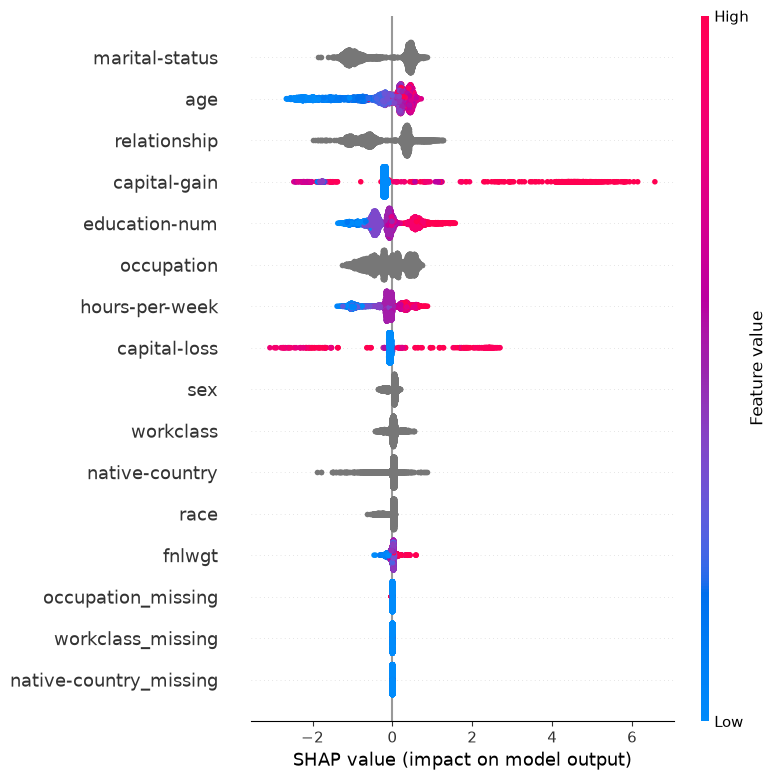

In [20]:
shap.summary_plot(shap_values, X_test)

Temuan kunci

1. capital-gain (urutan ke-4) — pola paling ekstrem

Perhatikan bentuknya: mayoritas titik menumpuk di sekitar 0 (abu-abu/biru, artinya capital-gain=0, mayoritas orang), tapi ada ekor panjang titik merah menjulur sampai SHAP value +6 lebih. Ini konfirmasi kuantitatif dari yang kita duga di EDA: sedikit orang yang punya capital-gain tinggi, tapi bagi mereka yang punya, ini pendorong sangat kuat ke arah >50K — bahkan salah satu pengaruh individual terbesar di seluruh dataset.

2. age (urutan ke-2) — pola jelas dan konsisten

Titik biru (usia muda) semuanya berada di sisi negatif (mendorong ke <=50K), titik merah (usia lebih tua) di sisi positif. Ini mengkonfirmasi hipotesis dari boxplot EDA kita sebelumnya — usia memang berpengaruh besar dan searah dengan dugaan awal.

3. education-num — konsisten juga dengan EDA

Warna merah (pendidikan tinggi) jelas di sisi positif, biru (pendidikan rendah) di sisi negatif — sama seperti pola monoton yang kita lihat di bar chart proporsi pendidikan sebelumnya.

4. marital-status, relationship, occupation — semuanya berwarna ABU-ABU, bukan gradien merah-biru

Ini penting untuk dipahami: warna abu-abu di summary plot SHAP muncul untuk fitur kategorikal yang nilainya bukan berupa skala numerik yang bisa diurutkan tinggi-rendah secara alami (beda dari age atau capital-gain yang jelas ada makna "tinggi" vs "rendah"). SHAP tidak tahu cara mewarnai "Married-civ-spouse vs Never-married" sebagai gradien, jadi ditampilkan netral (abu-abu). Ini bukan bug — ini keterbatasan visual summary plot untuk kolom kategorikal.

5. sex, workclass, race, native-country, fnlwgt — pengaruh relatif kecil
Sebaran titiknya sempit di sekitar 0, artinya kontribusi individual fitur-fitur ini terhadap prediksi cenderung kecil dibanding fitur-fitur di atas.

6. *_missing flags — hampir tidak berpengaruh

Ketiga kolom indikator missingness yang kamu buat (occupation_missing, workclass_missing, native-country_missing) berada di paling bawah dengan sebaran sangat sempit — artinya informasi "apakah data ini hilang atau tidak" ternyata tidak terlalu prediktif buat income, walau tetap berguna untuk XGBoost menangani nilai kosong tadi.


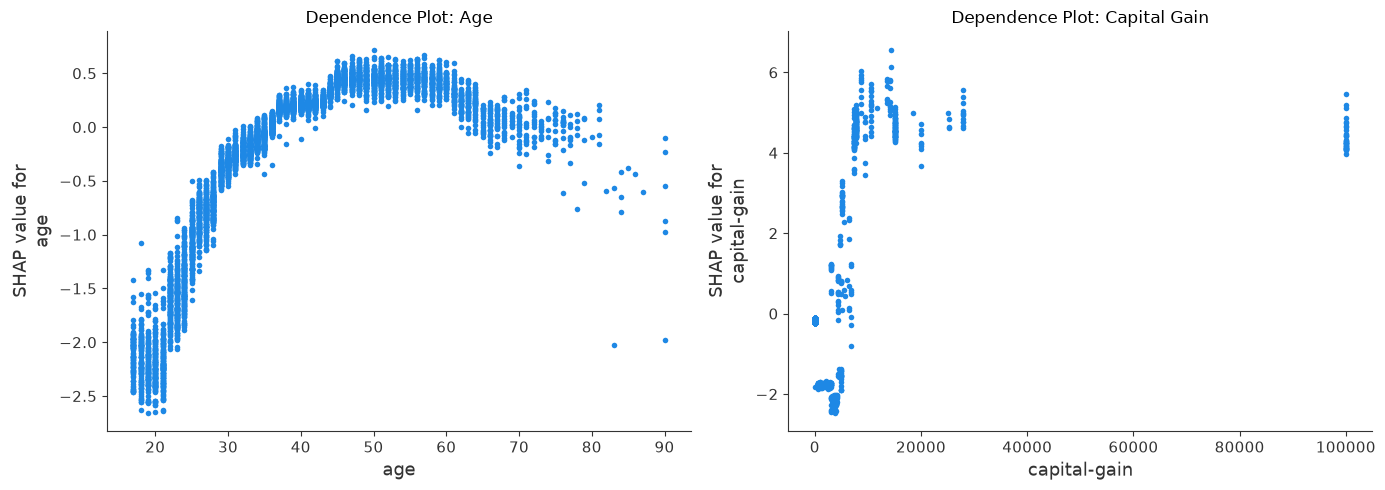

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

shap.dependence_plot('age', shap_values, X_test, interaction_index=None, ax=axes[0], show=False)
axes[0].set_title('Dependence Plot: Age')

shap.dependence_plot('capital-gain', shap_values, X_test, interaction_index=None, ax=axes[1], show=False)
axes[1].set_title('Dependence Plot: Capital Gain')

plt.tight_layout()
plt.show()

In [25]:
dmatrix_sample = xgb.DMatrix(X_sample, enable_categorical=True)
shap_interaction_values = best_model.get_booster().predict(dmatrix_sample, pred_interactions=True)
print(shap_interaction_values.shape)

(500, 17, 17)


In [26]:
shap_interaction_values = shap_interaction_values[:, :-1, :-1]
print(shap_interaction_values.shape)

(500, 16, 16)


In [28]:
mean_abs_interaction = np.abs(shap_interaction_values).mean(axis=0)
print(mean_abs_interaction.shape)

(16, 16)


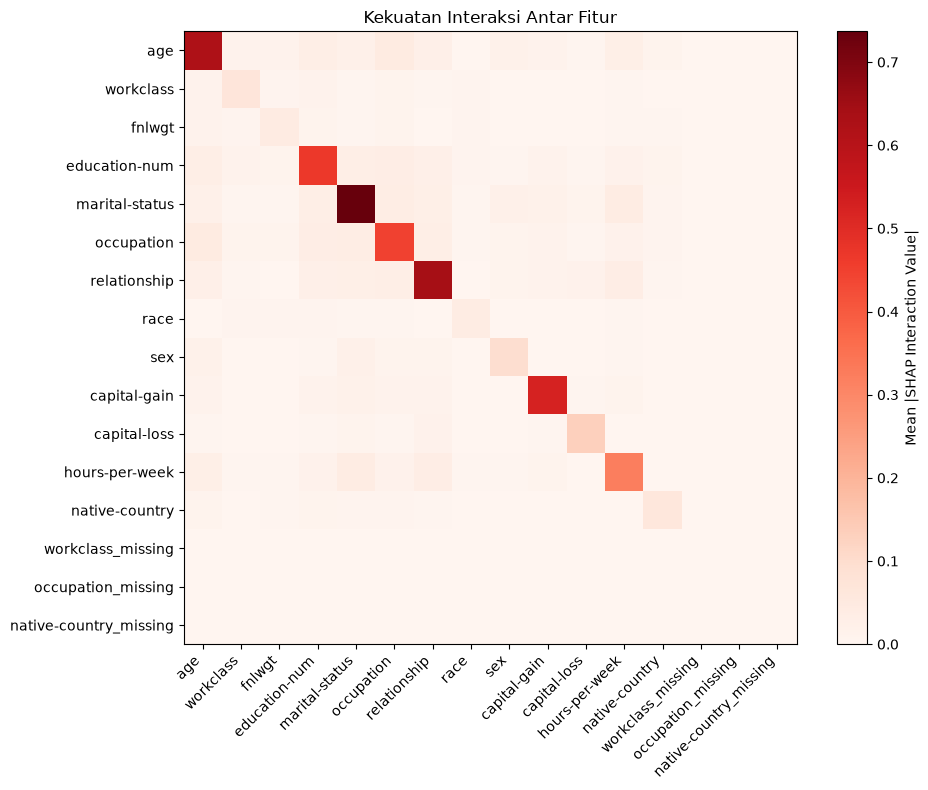

In [29]:
feature_names = X_sample.columns.tolist()

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(mean_abs_interaction, cmap='Reds')

ax.set_xticks(range(len(feature_names)))
ax.set_yticks(range(len(feature_names)))
ax.set_xticklabels(feature_names, rotation=45, ha='right')
ax.set_yticklabels(feature_names)

plt.colorbar(im, label='Mean |SHAP Interaction Value|')
plt.title('Kekuatan Interaksi Antar Fitur')
plt.tight_layout()
plt.show()

In [32]:
shap_values_sample = explainer.shap_values(X_sample)
shap_values_sample

array([[ 4.4246995e-01, -1.4173898e-01,  7.1446626e-03, ...,
        -5.3347940e-05,  4.1946951e-05, -7.7130117e-06],
       [-1.4300466e+00, -3.2373063e-02, -8.0344282e-02, ...,
         4.9558879e-05,  2.4401666e-04, -4.1025339e-04],
       [ 2.5570709e-01,  4.6536580e-02,  1.2567277e-01, ...,
         5.0915361e-05,  2.3599759e-04, -8.6559576e-06],
       ...,
       [ 5.6185588e-02,  8.1612378e-02, -1.7291984e-02, ...,
         2.0314335e-05,  2.5375289e-04, -2.6044219e-05],
       [-4.1385671e-01,  7.7460213e-03,  1.9071998e-02, ...,
         4.6950034e-05,  2.5174220e-04, -1.4679962e-04],
       [ 1.1889562e-01,  9.1092832e-02,  2.8772850e-02, ...,
         2.0314335e-05,  2.5375289e-04, -1.6026486e-05]],
      shape=(500, 16), dtype=float32)

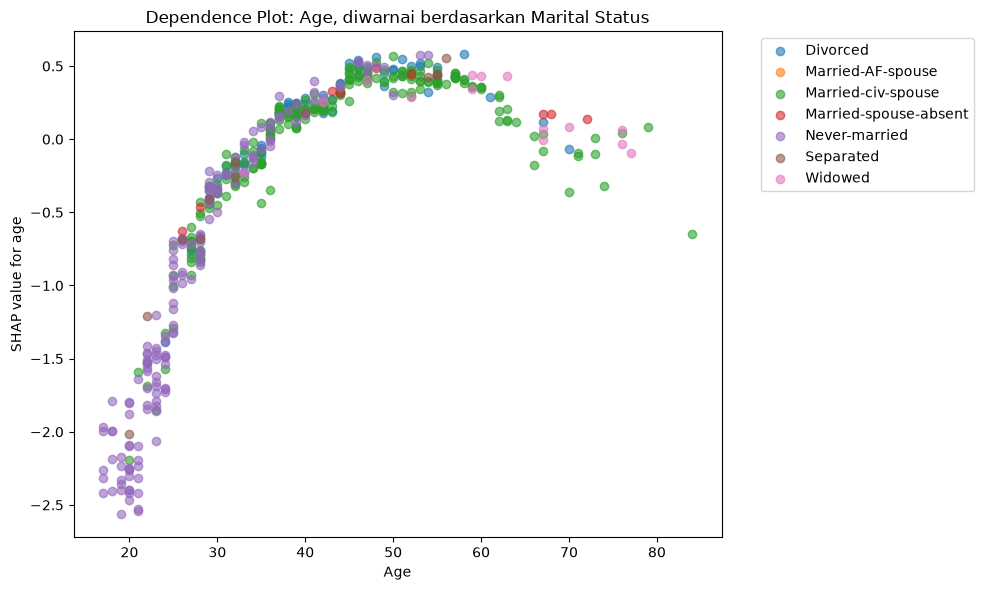

In [34]:
X_sample = X_test.sample(n=500, random_state=42)

fig, ax = plt.subplots(figsize=(10, 6))

feature_idx = X_sample.columns.get_loc('age')

for status in X_sample['marital-status'].cat.categories:
    mask = (X_sample['marital-status'] == status).values
    ax.scatter(
        X_sample['age'][mask],
        shap_values_sample[mask, feature_idx],
        label=status,
        alpha=0.6
    )

ax.set_xlabel('Age')
ax.set_ylabel('SHAP value for age')
ax.set_title('Dependence Plot: Age, diwarnai berdasarkan Marital Status')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [39]:
data['native-country'].value_counts()

native-country
United-States                 29170
Mexico                          643
Philippines                     198
Germany                         137
Canada                          121
Puerto-Rico                     114
El-Salvador                     106
India                           100
Cuba                             95
England                          90
Jamaica                          81
South                            80
China                            75
Italy                            73
Dominican-Republic               70
Vietnam                          67
Guatemala                        64
Japan                            62
Poland                           60
Columbia                         59
Taiwan                           51
Haiti                            44
Iran                             43
Portugal                         37
Nicaragua                        34
Peru                             31
France                           29
Greece       

In [40]:
# Simpan model
joblib.dump(best_model, 'model.pkl')

# Simpan daftar kategori tiap kolom (PENTING untuk konsistensi inference)
category_mapping = {
    col: X_train[col].cat.categories.tolist()
    for col in X_train.select_dtypes(include='category').columns
}
with open('category_mapping.json', 'w') as f:
    json.dump(category_mapping, f)

print("Export selesai:", ['model.pkl', 'category_mapping.json'])

Export selesai: ['model.pkl', 'category_mapping.json']
